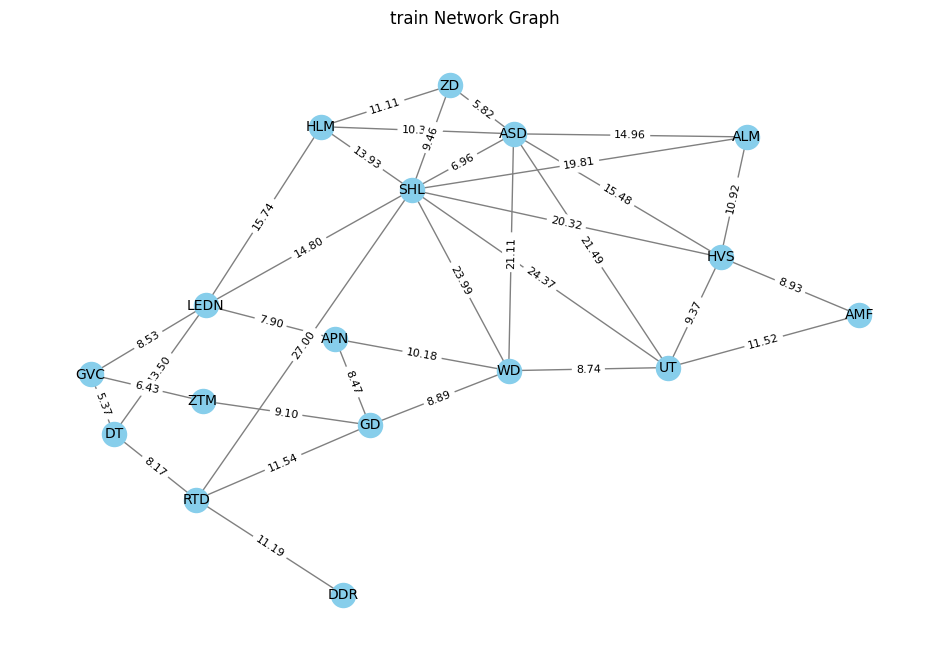

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

NETWORK_TYPE = "train"
# NETWORK_TYPE = "car"

# Load CSVs
nodes_df = pd.read_csv(f"network_nodes_{NETWORK_TYPE}.csv")  # columns: name, station, lat, lng
edges_df = pd.read_csv(f"network_edges_{NETWORK_TYPE}.csv")  # columns: from, to, travel_time

# Create undirected graph
G_red = nx.Graph()

# Add nodes with attributes
for _, row in nodes_df.iterrows():
    G_red.add_node(row['name'], lat=row['lat'], lon=row['lng'], station=row['station'])

# Add edges from CSV
for _, row in edges_df.iterrows():
    G_red.add_edge(row['from'], row['to'], weight=row['travel_time'])

# Positions based on lon/x and lat/y
pos = {node: (data['lon'], data['lat']) for node, data in G_red.nodes(data=True)}

# Plot the graph
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G_red, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(G_red, pos, edge_color='gray')  # undirected, no arrows
nx.draw_networkx_labels(G_red, pos, font_size=10, font_color='black')

# Edge labels = travel_time rounded to 2 decimals
edge_labels = { (u,v): f"{d['weight']:.2f}" for u,v,d in G_red.edges(data=True) }
nx.draw_networkx_edge_labels(G_red, pos, edge_labels=edge_labels, font_size=8)

plt.title(f"{NETWORK_TYPE} Network Graph")
plt.axis('off')
plt.show()

In [18]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    lon1 = np.radians(lon1)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [19]:
def calculate_travel_time(G, node1, node2, km_to_time=0.572):
    lat1 = G.nodes[node1]['lat']
    lon1 = G.nodes[node1]['lon']
    lat2 = G.nodes[node2]['lat']
    lon2 = G.nodes[node2]['lon']
    
    distance_km = haversine(lat1, lon1, lat2, lon2)
    travel_time = distance_km * km_to_time
    return travel_time

In [ ]:
def evaluate_all_possible_new_edges(G, km_to_time=0.572):
    candidates = []

    for node1, node2 in combinations(G.nodes(), 2):
        # Skip if edge already exists
        if G.has_edge(node1, node2):
            continue

        # Estimate travel time for this new connection
        new_weight = calculate_travel_time(G, node1, node2, km_to_time=km_to_time)

        # Create modified graph with this single added edge
        G_modified = G.copy()
        G_modified.add_edge(node1, node2, weight=new_weight)

        candidates.append({
            "from_node": node1,
            "to_node": node2,
            "estimated_weight": new_weight,
            "G_modified": G_modified
        })

    return candidates

In [23]:
all_candidates = evaluate_all_possible_new_edges(G_red)

print(f"Number of possible new single-edge additions: {len(all_candidates)}")

# Example: inspect first few candidates
for c in all_candidates[:5]:
    print(c["from_node"], "->", c["to_node"], "| weight =", round(c["estimated_weight"], 2))

Number of possible new single-edge additions: 102
ALM -> APN | weight = 27.01
ALM -> AMF | weight = 15.27
ALM -> DT | weight = 40.95
ALM -> GVC | weight = 39.51
ALM -> DDR | weight = 42.01


In [25]:
def plot_graph_with_highlight(G, new_edge, title="Graph"):
    pos = {node: (data['lon'], data['lat']) for node, data in G.nodes(data=True)}

    plt.figure(figsize=(12, 8))

    # draw all edges
    nx.draw_networkx_edges(G, pos, edge_color='gray')

    # highlight new edge
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[new_edge],
        edge_color='red',
        width=2
    )

    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='skyblue')
    nx.draw_networkx_labels(G, pos, font_size=10)

    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.axis('off')
    plt.show()

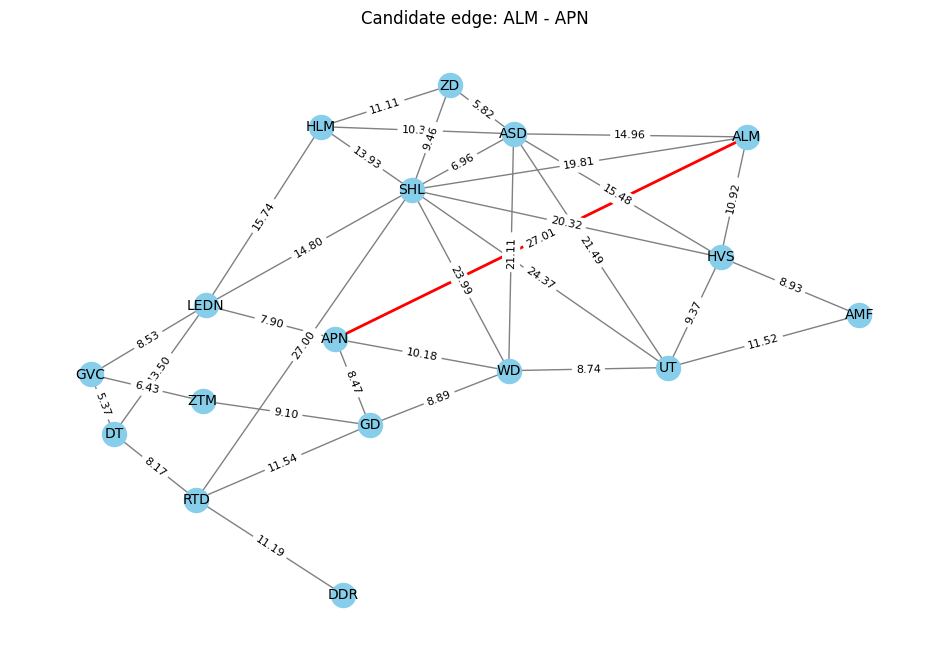

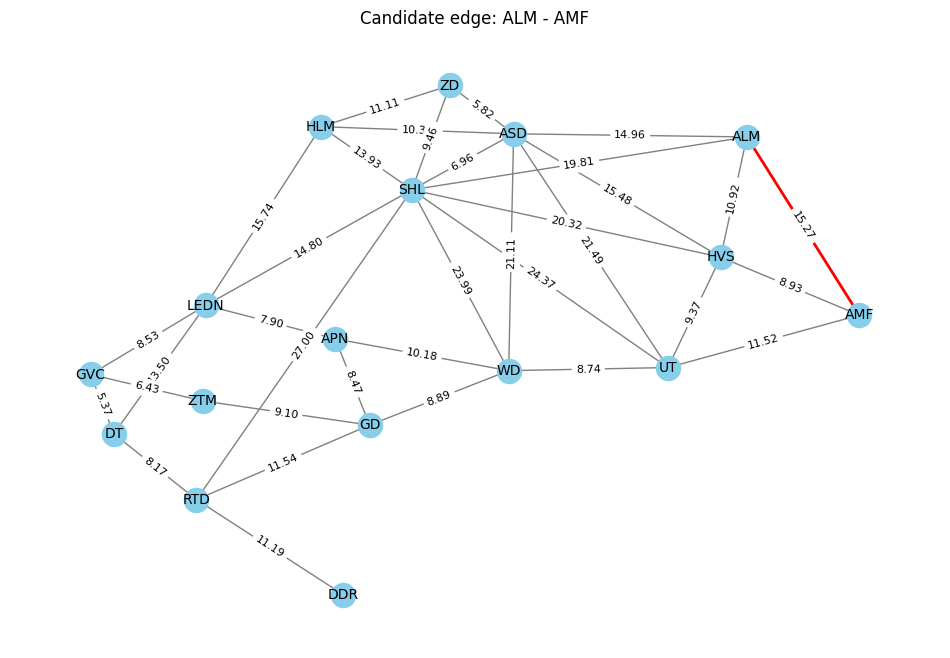

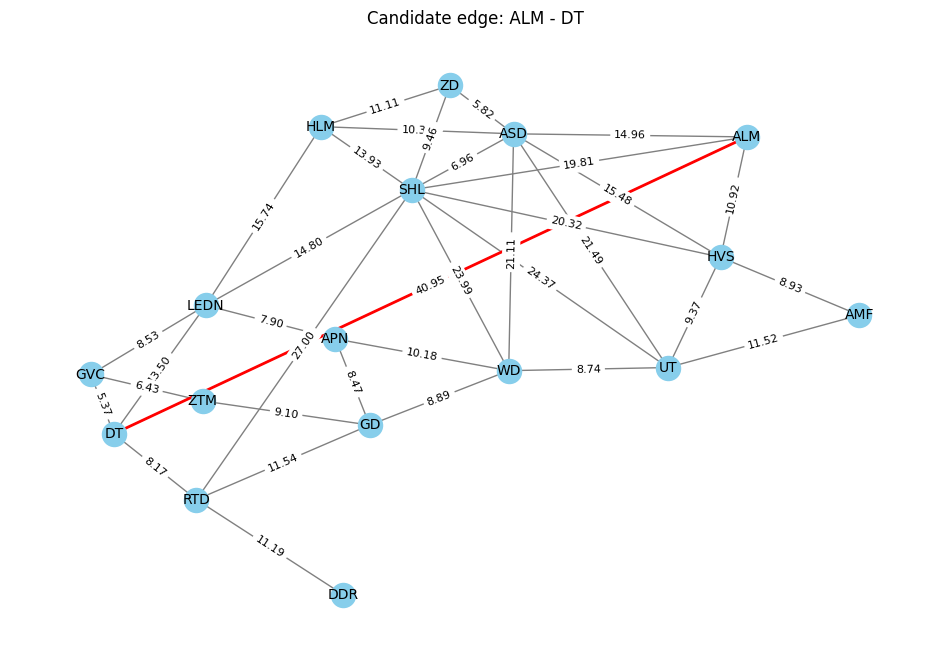

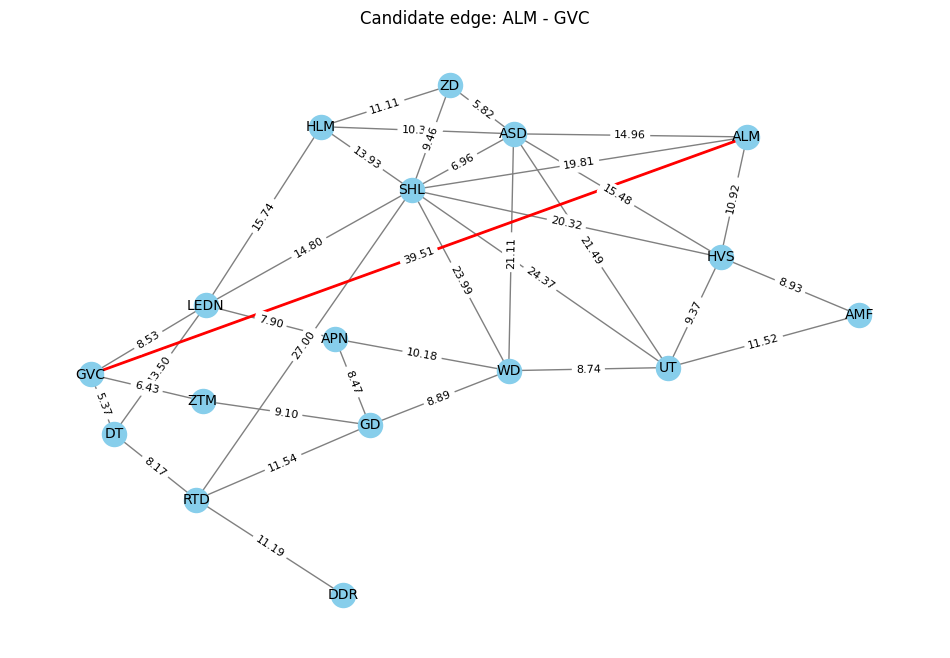

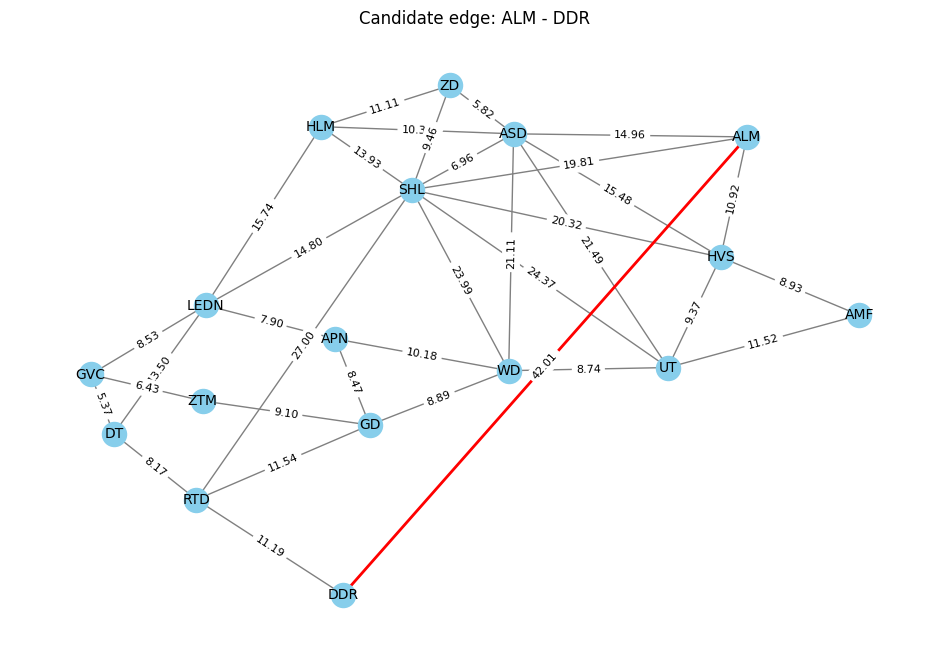

In [27]:
for c in all_candidates[:5]:
    G_test = G_red.copy()
    G_test.add_edge(c["from_node"], c["to_node"], weight=c["estimated_weight"])

    plot_graph_with_highlight(
        G_test,
        (c["from_node"], c["to_node"]),
        title=f"Candidate edge: {c['from_node']} - {c['to_node']}"
    )